# Notebook 12 — CNN Spatial Decoder

**Core idea:**  
The 8 stabilisers of a d=3 surface code sit on a 2D lattice.  
Instead of treating them as a flat vector or a sequence, we reshape them  
onto their actual 2D grid and apply convolutional filters — the same way  
image classifiers find patterns in photos.

**Why this is physically motivated:**  
Error clusters in a surface code are *spatially local* — a single qubit error  
triggers stabilisers in a small neighbourhood. A 3×3 convolutional filter  
naturally detects exactly these local clusters, without being told to.

**d=3 stabiliser grid layout (4 X-type + 4 Z-type in a 3×3 patch):**
```
X0  .  X1
 .  Z3  .
X2  .  X3

Z0  .  Z1  
 .  X3  .
Z2  .  Z3
```
We use a (2, 3, 3) spatial layout — 2 channels (X and Z), 3×3 grid.

**Input reshape:** `(N, 9, 8)` → `(N, 9, 2, 3, 3)` → 2D conv over (3×3) per round  
**Advantage:** Fastest inference of all NN decoders. Filters are interpretable.

**Prerequisite:** Run notebook 01 first.
```bash
pip install torch scikit-learn numpy matplotlib
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import os, time, warnings
warnings.filterwarnings('ignore')

SEED   = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROUNDS, STABS = 9, 8
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")

Device  : cuda
PyTorch : 2.10.0+cu128


---
## 1. Spatial Reshape

Map the 8 stabilisers onto a 2-channel 3×3 grid.  
Channel 0 = X-type stabilisers, Channel 1 = Z-type stabilisers.

In [2]:
# d=3 rotated surface code: 4 X-stabilisers + 4 Z-stabilisers
# Detector indices 0-3: X-type stabilisers
# Detector indices 4-7: Z-type stabilisers
# (This ordering follows Stim's default detector ordering for rotated_memory_z)

# 3x3 grid positions for each stabiliser type
# X-type at positions: (0,0), (0,2), (2,0), (2,2)  — corners
# Z-type at positions: (0,1), (1,0), (1,2), (2,1)  — edges
X_POSITIONS = [(0,0), (0,2), (2,0), (2,2)]   # X-type stabilisers → channel 0
Z_POSITIONS = [(0,1), (1,0), (1,2), (2,1)]   # Z-type stabilisers → channel 1


def to_spatial(det_seq):
    """
    Convert detection events to spatial grid representation.

    Input : (N, 9, 8)   flat detectors per round
    Output: (N, 9, 2, 3, 3)  2-channel spatial grid per round

    Channel 0: X-type stabilisers at their grid positions
    Channel 1: Z-type stabilisers at their grid positions
    """
    N, R, S = det_seq.shape
    spatial  = np.zeros((N, R, 2, 3, 3), dtype=np.float32)

    # Fill X-type stabilisers (detectors 0-3) into channel 0
    for idx, (row, col) in enumerate(X_POSITIONS):
        spatial[:, :, 0, row, col] = det_seq[:, :, idx]

    # Fill Z-type stabilisers (detectors 4-7) into channel 1
    for idx, (row, col) in enumerate(Z_POSITIONS):
        spatial[:, :, 1, row, col] = det_seq[:, :, idx + 4]

    return spatial   # (N, 9, 2, 3, 3)


# Verify
test_seq = np.random.randn(10, 9, 8).astype(np.float32)
test_sp  = to_spatial(test_seq)
print(f"Flat seq shape    : {test_seq.shape}")
print(f"Spatial grid shape: {test_sp.shape}  (N, rounds, channels, H, W)")
print()
print("Grid layout for a single round:")
print("  Channel 0 (X-type):")
print("    Stabiliser 0 at (0,0)  |  Stabiliser 1 at (0,2)")
print("    Stabiliser 2 at (2,0)  |  Stabiliser 3 at (2,2)")
print("  Channel 1 (Z-type):")
print("    Stabiliser 4 at (0,1)  |  Stabiliser 5 at (1,0)")
print("    Stabiliser 6 at (1,2)  |  Stabiliser 7 at (2,1)")

Flat seq shape    : (10, 9, 8)
Spatial grid shape: (10, 9, 2, 3, 3)  (N, rounds, channels, H, W)

Grid layout for a single round:
  Channel 0 (X-type):
    Stabiliser 0 at (0,0)  |  Stabiliser 1 at (0,2)
    Stabiliser 2 at (2,0)  |  Stabiliser 3 at (2,2)
  Channel 1 (Z-type):
    Stabiliser 4 at (0,1)  |  Stabiliser 5 at (1,0)
    Stabiliser 6 at (1,2)  |  Stabiliser 7 at (2,1)


---
## 2. CNN Model

Applies 2D convolutions over the stabiliser grid at each syndrome round,  
then uses a 1D temporal convolution to combine across rounds.

In [3]:
class CNNDecoder(nn.Module):
    """
    CNN-based surface code decoder.

    Input : (batch, rounds=9, channels=2, H=3, W=3)
    Output: (batch,) raw logit

    Spatial CNN extracts local error patterns per round.
    Temporal CNN combines across rounds.
    """
    def __init__(self, in_channels=2, spatial_filters=16,
                 temporal_filters=32, dropout=0.2):
        super().__init__()

        # ── Spatial CNN: process the 3x3 grid per round ────────────────────
        # Input: (batch*rounds, channels=2, 3, 3)
        self.spatial_cnn = nn.Sequential(
            # 3x3 conv with padding=1 keeps spatial dimensions
            nn.Conv2d(in_channels, spatial_filters,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(spatial_filters),
            nn.ReLU(),
            # Second layer: detect combinations of local patterns
            nn.Conv2d(spatial_filters, spatial_filters,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(spatial_filters),
            nn.ReLU(),
            # Global average pool: (batch*rounds, filters, 3, 3) → (batch*rounds, filters)
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
        )

        # ── Temporal CNN: combine across syndrome rounds ───────────────────
        # Input: (batch, spatial_filters, rounds)  — rounds as time dimension
        self.temporal_cnn = nn.Sequential(
            nn.Conv1d(spatial_filters, temporal_filters,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(temporal_filters),
            nn.ReLU(),
            nn.Conv1d(temporal_filters, temporal_filters,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(temporal_filters),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
        )

        # ── Classification head ────────────────────────────────────────────
        self.head = nn.Sequential(
            nn.Linear(temporal_filters, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        """
        x: (batch, rounds, channels, H, W)
        """
        batch, rounds, C, H, W = x.shape

        # Process each round through spatial CNN
        x_flat = x.reshape(batch * rounds, C, H, W)    # merge batch and rounds
        spatial_features = self.spatial_cnn(x_flat)    # (batch*rounds, filters)
        spatial_features = spatial_features.reshape(batch, rounds, -1)  # (batch, rounds, filters)

        # Temporal CNN over rounds
        temporal_input = spatial_features.permute(0, 2, 1)  # (batch, filters, rounds)
        temporal_features = self.temporal_cnn(temporal_input)  # (batch, temporal_filters)

        return self.head(temporal_features).squeeze(-1)   # (batch,)


demo = CNNDecoder()
total = sum(p.numel() for p in demo.parameters())
print(f"CNN decoder: {total:,} parameters")

# Forward pass check
x_test = torch.randn(4, 9, 2, 3, 3)
out    = demo(x_test)
print(f"Forward pass: input {x_test.shape} → output {out.shape}  ✓")

CNN decoder: 7,937 parameters
Forward pass: input torch.Size([4, 9, 2, 3, 3]) → output torch.Size([4])  ✓


---
## 3. Load Data, Reshape, Train

In [4]:
det = np.load("data/detection_events.npy").astype(np.float32)
obs = np.load("data/observable_flips.npy").astype(np.float32).squeeze()

# Reshape to spatial
det_seq     = det.reshape(-1, ROUNDS, STABS)
det_spatial = to_spatial(det_seq)   # (N, 9, 2, 3, 3)

idx = np.arange(len(obs))
idx_tr, idx_tmp = train_test_split(idx, test_size=0.30,
                                    stratify=obs.astype(int), random_state=SEED)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50,
                                    stratify=obs[idx_tmp].astype(int), random_state=SEED)

sp_tr,  obs_tr  = det_spatial[idx_tr],  obs[idx_tr]
sp_val, obs_val = det_spatial[idx_val], obs[idx_val]
sp_te,  obs_te  = det_spatial[idx_te],  obs[idx_te]
trivial_ler = obs_te.mean()

print(f"Spatial data shape: {det_spatial.shape}")
print(f"Trivial LER: {trivial_ler:.4f}")

Spatial data shape: (100000, 9, 2, 3, 3)
Trivial LER: 0.0549


In [5]:
def make_loader(X, y, batch_size=512, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

@torch.no_grad()
def predict(model, X, batch_size=1024):
    model.eval()
    ds = TensorDataset(torch.tensor(X))
    loader = DataLoader(ds, batch_size=batch_size)
    out = []
    for (Xb,) in loader:
        out.append((torch.sigmoid(model(Xb.to(DEVICE))) > 0.5).cpu().numpy())
    return np.concatenate(out)

model      = CNNDecoder().to(DEVICE)
optimizer  = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=6, factor=0.5)
pos_weight = torch.tensor([(1-obs_tr.mean())/obs_tr.mean()]).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
tr_loader  = make_loader(sp_tr,  obs_tr)
val_loader = make_loader(sp_val, obs_val, shuffle=False)

EPOCHS, PATIENCE = 120, 15
history = {'tr_ler': [], 'val_ler': [], 'tr_loss': [], 'val_loss': []}
best_vl, best_ep, best_st = np.inf, 0, None
t0 = time.time()

print("Training CNN decoder...")
for epoch in range(1, EPOCHS+1):
    model.train()
    tl, tc, tt = 0.0, 0, 0
    for Xb, yb in tr_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(Xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tc += ((torch.sigmoid(logits)>0.5).float()==yb).sum().item()
        tt += len(yb); tl += loss.item()*len(yb)

    model.eval()
    vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits = model(Xb)
            vl += criterion(logits, yb).item()*len(yb)
            vc += ((torch.sigmoid(logits)>0.5).float()==yb).sum().item()
            vt += len(yb)
    val_ler  = 1-vc/vt
    val_loss = vl/vt
    scheduler.step(val_loss)

    for k,v in zip(['tr_loss','val_loss','tr_ler','val_ler'],
                   [tl/tt,val_loss,1-tc/tt,val_ler]):
        history[k].append(v)

    if val_loss < best_vl:
        best_vl=val_loss; best_ep=epoch
        best_st={k:v.cpu().clone() for k,v in model.state_dict().items()}

    if epoch%20==0 or epoch==1:
        print(f"  Epoch {epoch:3d}  tr_LER={1-tc/tt:.5f}  val_LER={val_ler:.5f}")
    if epoch-best_ep >= PATIENCE:
        print(f"  Early stop at epoch {epoch} (best={best_ep})"); break

model.load_state_dict(best_st)
pred_cnn = predict(model, sp_te)
ler_cnn  = float((pred_cnn != obs_te).mean())

print(f"\nDone in {time.time()-t0:.1f}s | best epoch={best_ep}")
print(f"  CNN Test LER : {ler_cnn:.5f}  ({100*ler_cnn:.4f}%)")
print(f"  Trivial LER  : {trivial_ler:.5f}  ({100*trivial_ler:.4f}%)")
print(f"  Improvement  : {trivial_ler/ler_cnn:.1f}x")

Training CNN decoder...
  Epoch   1  tr_LER=0.24116  val_LER=0.02827
  Epoch  20  tr_LER=0.01496  val_LER=0.00880
  Epoch  40  tr_LER=0.01290  val_LER=0.01080
  Epoch  60  tr_LER=0.00986  val_LER=0.00760
  Early stop at epoch 62 (best=47)

Done in 66.1s | best epoch=47
  CNN Test LER : 0.00867  (0.8667%)
  Trivial LER  : 0.05487  (5.4867%)
  Improvement  : 6.3x


---
## 4. Visualise Learned Spatial Filters

The convolutional filters are directly interpretable —  
they reveal what spatial patterns the CNN learned to detect.

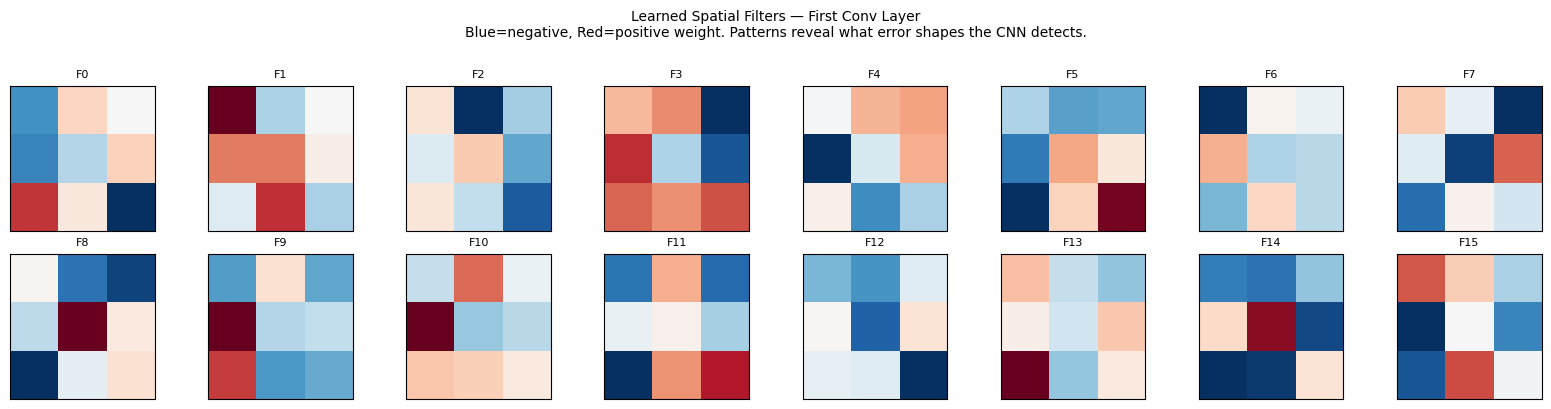

Saved → figures/12_cnn_filters.png

Interpretation:
  A filter with a strong centre = detects isolated errors
  A filter with a 2-patch pattern = detects a pair of adjacent errors
  A filter resembling the MWPM shortest path = the CNN is learning MWPM-like logic


In [6]:
# Extract first conv layer filters: (spatial_filters, in_channels=2, 3, 3)
filters = model.spatial_cnn[0].weight.data.cpu().numpy()   # (16, 2, 3, 3)
n_filters = filters.shape[0]

fig, axes = plt.subplots(2, n_filters // 2, figsize=(16, 4))
axes = axes.flatten()

for i in range(n_filters):
    # Show mean over channels for each filter
    filt = filters[i].mean(axis=0)   # (3, 3)
    vmax = np.abs(filt).max()
    axes[i].imshow(filt, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[i].set_title(f'F{i}', fontsize=8)
    axes[i].set_xticks([]); axes[i].set_yticks([])

plt.suptitle('Learned Spatial Filters — First Conv Layer\n'
             'Blue=negative, Red=positive weight. Patterns reveal what error shapes the CNN detects.',
             fontsize=10, y=1.01)
plt.tight_layout()
fig.savefig('figures/12_cnn_filters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/12_cnn_filters.png")
print()
print("Interpretation:")
print("  A filter with a strong centre = detects isolated errors")
print("  A filter with a 2-patch pattern = detects a pair of adjacent errors")
print("  A filter resembling the MWPM shortest path = the CNN is learning MWPM-like logic")

---
## 5. Noise Sweep & Save

In [7]:
NOISE_LEVELS = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02]
cnn_sweep = []

print("CNN noise sweep")
print(f"  {'p':>8}  {'Trivial':>10}  {'CNN LER':>10}  {'Ratio':>7}")
print("  " + "-"*42)

for p in NOISE_LEVELS:
    tag    = f"{int(p*10000):04d}"
    det_s  = np.load(f"data/sweep/det_p{tag}.npy").astype(np.float32)
    obs_s  = np.load(f"data/sweep/obs_p{tag}.npy").astype(np.float32).squeeze()
    seq_s  = det_s.reshape(-1, ROUNDS, STABS)
    sp_s   = to_spatial(seq_s)
    pred_s = predict(model, sp_s)
    ler_s  = float((pred_s != obs_s).mean())
    triv_s = float(obs_s.mean())
    ratio  = triv_s/ler_s if ler_s > 0 else float('inf')
    cnn_sweep.append((p, ler_s))
    print(f"  p={p:.4f}  {100*triv_s:8.3f}%  {100*ler_s:8.3f}%  {ratio:5.1f}x")

os.makedirs("results", exist_ok=True)
np.save("results/cnn_sweep.npy", np.array(cnn_sweep))

os.makedirs("models", exist_ok=True)
torch.save({
    'model_state': model.state_dict(),
    'test_ler':    ler_cnn,
    'history':     history,
    'x_positions': X_POSITIONS,
    'z_positions': Z_POSITIONS,
}, "models/decoder_cnn.pt")
print(f"\nSaved → models/decoder_cnn.pt  (test_ler={ler_cnn:.5f})")
print("Saved → results/cnn_sweep.npy")

CNN noise sweep
         p     Trivial     CNN LER    Ratio
  ------------------------------------------
  p=0.0005     2.794%     0.276%   10.1x
  p=0.0010     5.446%     0.988%    5.5x
  p=0.0020    10.400%     3.420%    3.0x
  p=0.0050    21.678%    14.834%    1.5x
  p=0.0100    34.436%    33.568%    1.0x
  p=0.0200    45.288%    48.604%    0.9x

Saved → models/decoder_cnn.pt  (test_ler=0.00867)
Saved → results/cnn_sweep.npy
